# 1. Project Overview

This notebook is the capstone artifact for **AI-Assisted GitOps Orchestration for Safe Helm Upgrades Across Multi-Cluster Kubernetes Platforms**.

The goal is to demonstrate an end-to-end upgrade workflow that combines:
- structured platform inventory analysis,
- deterministic risk scoring,
- agentic release-note research,
- Helm validation,
- health-gate enforcement,
- GitOps change generation, and
- explicit human approval before PROD promotion.

All demonstrations use the actual `src/` modules, synthetic platform data, Helm charts, scenario files, and configuration already present in this repository.


# 2. Industry Problem Statement

Enterprise platform teams rarely upgrade Helm-managed services in a single cluster. They coordinate upgrades across **multiple departments, regions, environments, and criticality tiers** while balancing availability, compliance, and rollback safety.

In practice, this creates four operational risks:

1. **Version drift** across clusters obscures the real blast radius.
2. **Release-note complexity** hides breaking changes and compatibility constraints.
3. **Operational pressure** can encourage unsafe assumptions when monitoring evidence is incomplete.
4. **Manual GitOps workflows** can slow response time and increase review burden when not supported by structured evidence.

This project addresses those risks by combining deterministic gates with narrowly scoped AI assistance: the LLM helps synthesise release-note evidence, but deterministic Python logic controls state transitions, validation, blocking conditions, and approval requirements.


# 3. Prior Project Integration Map

The notebook intentionally integrates techniques from prior Udacity projects into a single production-style orchestration workflow.

| Prior project | Imported technique | Where it appears here | Repository module(s) |
|---|---|---|---|
| Project 2 (Statistical Data Analysis) | Pandas EDA, null analysis, descriptive statistics, distribution plots | Inventory profiling and upgrade history analysis | `src/inventory.py` |
| Project 3 (Applied ML — LSTM Fraud Detection) | Feature-style risk factor weighting and threshold-based classification | Deterministic upgrade risk score and risk banding | `src/risk.py` |
| Project 5 (Generative AI) | Structured synthesis of unstructured text into actionable outputs | Release-note summarisation into `ResearchReport` findings | `src/agents.py`, `src/knowledge.py` |
| Project 6a (agentic-ai-capstone) | Tool-registry enforcement, audit-logging, approved-tool boundary | `ToolRegistry`, `UpgradeResearchAgent` | `src/agents.py` |
| Project 6b (agentic-ai-beaver-choice multi-agent pattern) | Sequential agent coordination and state-machine orchestration | `UpgradeCoordinator.run()` workflow | `src/orchestrator.py` |

The result is not a collection of disconnected demos; it is a single integrated AI-assisted GitOps safety pipeline.


# 4. System Architecture Overview

The architecture is organised as a **deterministic coordinator** supervising specialised agents and validation utilities.

The system architecture is shown below. An architecture diagram is also available at `diagrams/architecture.png`.

```text
UpgradeRequest
     |
     v
+---------------------+
| UpgradeCoordinator  |
| state machine       |
+---------------------+
   |        |        |        |        |
   |        |        |        |        |
   v        v        v        v        v
Inventory  Research  Risk    Helm     Health
Agent      Agent     Planner Validation Gates
   |          |         |        |        |
   +----------+---------+--------+--------+
                      |
                      v
             Proposed GitOps Changes
                      |
                      v
             Awaiting Human Approval
                      |
                      v
               PROD promotion decision
```

**Architecture description**:
- **Inventory analysis** identifies affected clusters, version drift, and data quality issues (deterministic).
- The **Research Agent** uses a tool-constrained retrieval workflow with LLM synthesis to inspect release notes and runbooks. Only registered tools (search_release_notes, search_runbook, get_kubernetes_compatibility) may be called.
- **Risk planning** converts observable evidence into a deterministic risk score.
- **Validation** runs Helm and YAML checks before deployment evidence is considered.
- The **Health Gate** prevents missing monitoring data from being treated as success.
- The **GitOps layer** proposes changes, but never applies production changes automatically.
- The **human approval checkpoint** is mandatory before PROD promotion.


# 5. Environment Setup and Imports

The next code cell configures the notebook runtime, inserts the repository on `sys.path`, loads environment variables, imports the actual `src/` modules, and initialises the OpenAI client with a safe fallback path.


In [1]:
import inspect
import json
import os
import shutil
import sys
import textwrap
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import openai
import pandas as pd
import yaml
from dotenv import load_dotenv
from IPython.display import Markdown, display

# Resolve project root relative to notebook location — works in any clone
PROJECT_ROOT = Path(__file__).parent.resolve() if "__file__" in dir() else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.agents import Tool, ToolRegistry, UpgradeResearchAgent, build_research_agent
from src.gitops import generate_proposed_change, write_proposed_changes
from src.helm_tools import _detect_secrets, helm_lint, helm_template, run_validation
from src.inventory import (
    analyse_upgrade_history,
    filter_affected_clusters,
    get_component_dependencies,
    kubernetes_version_groups,
    load_cluster_inventory,
    run_inventory_analysis,
    summarise_version_distribution,
    upgrade_success_rate,
    validate_inventory_schema,
)
from src.knowledge import run_upgrade_research
from src.models import Environment, GateResult, HealthSnapshot, ResearchStatus, UpgradeRequest, UpgradeState
from src.monitoring import evaluate_health, load_quality_gates
from src.orchestrator import UpgradeCoordinator
from src.reporting import load_audit_log
from src.risk import build_upgrade_plan, calculate_risk_score, load_risk_rules

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = PROJECT_ROOT / 'data'
CONFIG_DIR = PROJECT_ROOT / 'config'
SCENARIO_DIR = PROJECT_ROOT / 'scenarios'
CHARTS_DIR = PROJECT_ROOT / 'charts'
ENVIRONMENTS_DIR = PROJECT_ROOT / 'environments'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'

INVENTORY_PATH = DATA_DIR / 'cluster_inventory.csv'
HISTORY_PATH = DATA_DIR / 'upgrade_history.csv'
DEPENDENCY_PATH = DATA_DIR / 'component_dependencies.csv'
RISK_RULES_PATH = CONFIG_DIR / 'risk_rules.yaml'
QUALITY_GATES_PATH = CONFIG_DIR / 'quality_gates.yaml'
RELEASE_NOTES_DIR = DATA_DIR / 'release_notes'
RUNBOOKS_DIR = DATA_DIR / 'runbooks'

# Load .env from project root (works after cloning — place your key in .env)
load_dotenv(PROJECT_ROOT / '.env')

try:
    client = openai.OpenAI()
    print('OpenAI client initialised.')
except Exception as e:
    client = None
    print(f'OpenAI client unavailable; notebook will use deterministic fallback: {e}')

print(f'Project root: {PROJECT_ROOT}')


OpenAI client unavailable; notebook will use deterministic fallback: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.
Project root: /Users/sheugumbie/projects/udacity/ai-helm-upgrade-orchestrator


# 6. Synthetic Platform Data

This section loads the synthetic inventory, dependency, and upgrade history data that drive the orchestration workflow.


In [2]:
inventory_df = load_cluster_inventory(INVENTORY_PATH)
history_df = pd.read_csv(HISTORY_PATH)
dependencies_df = pd.read_csv(DEPENDENCY_PATH)

print(f'Inventory shape: {inventory_df.shape}')
print(f'Upgrade history shape: {history_df.shape}')
print(f'Dependency table shape: {dependencies_df.shape}')

display(inventory_df.head(10))
display(history_df.head(10))
display(dependencies_df)


Inventory shape: (16, 11)
Upgrade history shape: (14, 15)
Dependency table shape: (7, 4)


,department,region,environment,cluster_name,kubernetes_version,component,chart_version,app_version,values_path,criticality,argocd_application
0,payments,eu-west-1,INT,payments-euw1-int,1.31,kafka-connect,0.18.2,7.8.1,environments/department-a/eu-west-1/int/connect.yaml,high,payments-int-connect
1,payments,eu-west-1,PROD,payments-euw1-prod,1.31,kafka-connect,0.18.2,7.8.1,environments/department-a/eu-west-1/prod/connect.yaml,critical,payments-prod-connect
2,payments,af-south-1,INT,payments-afs-int,1.30,kafka-connect,0.17.5,7.7.3,environments/department-a/af-south-1/int/connect.yaml,high,payments-afs-int-connect
3,payments,af-south-1,PROD,payments-afs-prod,1.30,kafka-connect,0.17.5,7.7.3,environments/department-a/af-south-1/prod/connect.yaml,critical,payments-afs-prod-connect
4,vehicle-services,eu-west-1,INT,vehicles-euw1-int,1.31,kafka-connect,0.18.2,7.8.1,environments/department-b/eu-west-1/int/connect.yaml,medium,vehicles-int-connect
5,vehicle-services,eu-west-1,PROD,vehicles-euw1-prod,1.31,kafka-connect,0.18.2,7.8.1,environments/department-b/eu-west-1/prod/connect.yaml,high,vehicles-prod-connect
6,vehicle-services,af-south-1,INT,vehicles-afs-int,1.26,kafka-connect,0.16.1,7.6.0,environments/department-b/af-south-1/int/connect.yaml,medium,vehicles-afs-int-connect
7,vehicle-services,af-south-1,PROD,vehicles-afs-prod,1.26,kafka-connect,0.16.1,7.6.0,environments/department-b/af-south-1/prod/connect.yaml,high,vehicles-afs-prod-connect
8,payments,eu-west-1,INT,payments-euw1-int,1.31,prometheus,25.1.0,2.51.2,environments/department-a/eu-west-1/int/prometheus.yaml,medium,payments-int-prometheus
9,payments,eu-west-1,PROD,payments-euw1-prod,1.31,prometheus,25.1.0,2.51.2,environments/department-a/eu-west-1/prod/prometheus.yaml,high,payments-prod-prometheus


,component,source_version,target_version,environment,department,region,duration_minutes,validation_result,pod_restart_count,error_rate_change_pct,cpu_change_pct,memory_change_pct,rollback_performed,final_outcome,incident_notes
0,kafka-connect,0.16.1,0.17.5,INT,vehicle-services,eu-west-1,23,passed,0,-1.2,3.1,2.4,False,success,NaN
1,kafka-connect,0.16.1,0.17.5,PROD,vehicle-services,eu-west-1,31,passed,1,-0.8,2.9,3.1,False,success,NaN
2,kafka-connect,0.17.5,0.18.2,INT,payments,eu-west-1,19,passed,0,-2.1,1.8,1.2,False,success,NaN
3,kafka-connect,0.17.5,0.18.2,PROD,payments,eu-west-1,27,passed,0,-1.5,2.2,1.8,False,success,NaN
4,kafka-connect,0.15.0,0.16.1,INT,vehicle-services,af-south-1,45,failed,8,25.3,18.7,12.1,True,rollback,Breaking change in connector config key naming
5,kafka-connect,0.18.0,0.18.2,INT,vehicle-services,af-south-1,15,passed,0,-0.5,0.8,0.3,False,success,Patch upgrade smooth
6,prometheus,24.0.0,25.0.0,INT,vehicle-services,eu-west-1,18,passed,0,-3.1,1.2,4.5,False,success,NaN
7,prometheus,24.0.0,25.0.0,PROD,vehicle-services,eu-west-1,22,passed,0,-2.8,1.4,4.2,False,success,NaN
8,prometheus,25.0.0,25.1.0,INT,payments,eu-west-1,12,passed,0,-1.0,0.5,0.8,False,success,Patch upgrade
9,grafana,7.3.10,7.3.12,INT,payments,eu-west-1,10,passed,0,-0.3,0.2,0.1,False,success,Minor patch


,component,dependency,constraint,notes
0,kafka-connect,kafka-broker,Compatible major version (e.g. CP 7.x requires Kafka 3.x),Confluent Platform versioning
1,kafka-connect,schema-registry,Compatible CP version,Required for Avro/Protobuf serialization
2,kafka-rest-proxy,kafka-broker,Compatible CP version,REST Proxy must match broker CP version
3,grafana,prometheus,Compatible data-source API version,Grafana datasource plugin compatibility
4,alertmanager,prometheus,Compatible alerting rule format,Must use same Prometheus version range
5,loki,grafana,Compatible Loki datasource plugin version,Grafana-Loki plugin version must match
6,argo-cd,kubernetes,Supported Kubernetes release (see Argo CD compatibility matrix),Argo CD 2.x supports K8s 1.26-1.31


In [3]:
inventory_scope_summary = (
    inventory_df.groupby(['component', 'environment'])['cluster_name']
    .count()
    .rename('cluster_count')
    .reset_index()
)

dependency_lookup = (
    dependencies_df.groupby('component')['dependency']
    .apply(list)
    .to_dict()
)

print('Cluster scope by component and environment:')
display(inventory_scope_summary)

print('Dependency lookup for key components:')
display(pd.DataFrame([
    {'component': component, 'dependencies': ', '.join(deps)}
    for component, deps in dependency_lookup.items()
]))


Cluster scope by component and environment:


,component,environment,cluster_count
0,grafana,INT,1
1,grafana,PROD,1
2,kafka-connect,INT,4
3,kafka-connect,PROD,4
4,loki,INT,1
5,loki,PROD,1
6,prometheus,INT,2
7,prometheus,PROD,2


Dependency lookup for key components:


,component,dependencies
0,alertmanager,prometheus
1,argo-cd,kubernetes
2,grafana,prometheus
3,kafka-connect,"kafka-broker, schema-registry"
4,kafka-rest-proxy,kafka-broker
5,loki,grafana


# 7. Statistical Data Quality Analysis

This section is **adapted from Project 2 (Statistical Data Analysis)**. The same EDA workflow used in earlier statistical profiling work is now applied to cluster inventory and historical upgrade outcomes.


In [4]:
print('Statistical data quality analysis adapted from Project 2 (Statistical Data Analysis).')

inventory_describe = inventory_df.describe(include='all').transpose()
inventory_nulls = inventory_df.isnull().sum().sort_values(ascending=False).to_frame('null_count')
schema_issues = validate_inventory_schema(inventory_df)
component_counts = inventory_df['component'].value_counts().rename_axis('component').reset_index(name='cluster_count')
kafka_version_distribution = (
    inventory_df[inventory_df['component'] == 'kafka-connect']['chart_version']
    .value_counts()
    .sort_index()
    .rename_axis('chart_version')
    .reset_index(name='cluster_count')
)

display(inventory_describe)
display(inventory_nulls)
display(component_counts)
display(kafka_version_distribution)

print('Schema/data-quality issues:', schema_issues if schema_issues else 'None detected')


Statistical data quality analysis adapted from Project 2 (Statistical Data Analysis).


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
department,16,2,payments,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,16,2,eu-west-1,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
environment,16,2,INT,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster_name,16,8,payments-euw1-int,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kubernetes_version,16.0,NaN,NaN,NaN,1.3025,0.016931,1.26,1.3075,1.31,1.31,1.31
component,16,4,kafka-connect,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chart_version,16,9,0.18.2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_version,16,9,7.8.1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
values_path,16,16,environments/department-a/eu-west-1/int/connect.yaml,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
criticality,16,4,high,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,null_count
department,0
region,0
environment,0
cluster_name,0
kubernetes_version,0
component,0
chart_version,0
app_version,0
values_path,0
criticality,0


,component,cluster_count
0,kafka-connect,8
1,prometheus,4
2,grafana,2
3,loki,2


,chart_version,cluster_count
0,0.16.1,2
1,0.17.5,2
2,0.18.2,4


Schema/data-quality issues: None detected


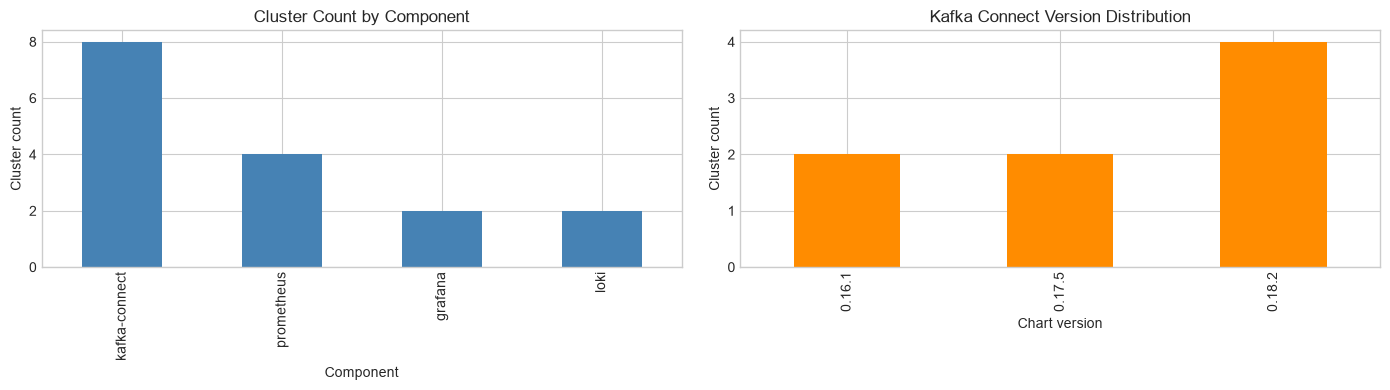

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

inventory_df['component'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', title='Cluster Count by Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Cluster count')

kafka_counts = inventory_df[inventory_df['component'] == 'kafka-connect']['chart_version'].value_counts().sort_index()
kafka_counts.plot(kind='bar', ax=axes[1], color='darkorange', title='Kafka Connect Version Distribution')
axes[1].set_xlabel('Chart version')
axes[1].set_ylabel('Cluster count')

plt.tight_layout()
plt.show()


In [6]:
print('Upgrade history statistics adapted from Project 2 (Statistical Data Analysis).')

history_numeric = history_df[
    ['duration_minutes', 'pod_restart_count', 'error_rate_change_pct', 'cpu_change_pct', 'memory_change_pct']
].describe().transpose()
history_outcomes = history_df['final_outcome'].value_counts().rename_axis('final_outcome').reset_index(name='count')
history_validation = history_df['validation_result'].value_counts().rename_axis('validation_result').reset_index(name='count')

display(history_numeric)
display(history_outcomes)
display(history_validation)


Upgrade history statistics adapted from Project 2 (Statistical Data Analysis).


,count,mean,std,min,25%,50%,75%,max
duration_minutes,14.0,22.642857,9.352969,10.0,18.000,21.0,26.000,45.0
pod_restart_count,14.0,0.785714,2.154729,0.0,0.000,0.0,0.000,8.0
error_rate_change_pct,14.0,0.621429,7.167145,-3.1,-1.725,-1.1,-0.575,25.3
cpu_change_pct,14.0,2.928571,4.671588,0.2,0.950,1.6,2.725,18.7
memory_change_pct,14.0,3.071429,3.167243,0.1,1.275,2.1,3.925,12.1


,final_outcome,count
0,success,13
1,rollback,1


,validation_result,count
0,passed,13
1,failed,1


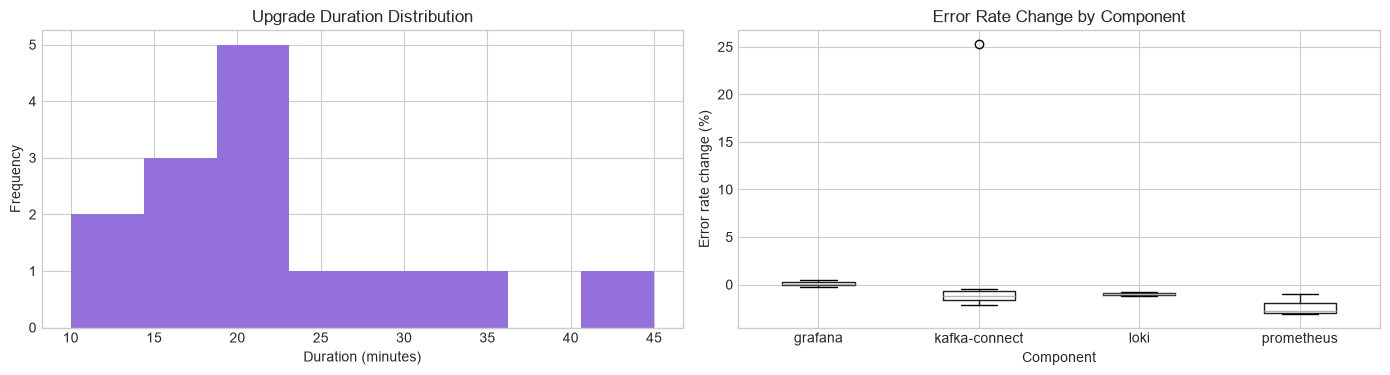

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

history_df['duration_minutes'].plot(kind='hist', bins=8, ax=axes[0], color='mediumpurple', title='Upgrade Duration Distribution')
axes[0].set_xlabel('Duration (minutes)')

history_df.boxplot(column='error_rate_change_pct', by='component', ax=axes[1])
axes[1].set_title('Error Rate Change by Component')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Error rate change (%)')
plt.suptitle('')

plt.tight_layout()
plt.show()


# 8. Agent and Tool Definitions

This section is **adapted from Project 6a (agentic-ai-capstone)** and implements a genuine bounded **ReAct (Reasoning + Acting) loop**.

## Bounded ReAct Loop

At each iteration, the `UpgradeResearchAgent`:

1. **Decision** — calls the LLM (or deterministic fallback) to choose the next action, receiving:
   - The upgrade request (component, chart version, app version)
   - All structured tool observations collected so far (findings, severity, source)
   - Available registered tools
2. **Action** — invokes the chosen tool through `ToolRegistry.call(name, arguments)`:
   - `search_release_notes(component, chart_version)` → `ReleaseNotesResult`
   - `search_runbook(component)` → `RunbookResult`
   - `get_kubernetes_compatibility(component, chart_version)` → `CompatibilityResult`
3. **Observation** — wraps the result in a validated `ToolObservation` and appends it to context
4. **Repeat** — until `FINISH` is chosen after all mandatory evidence is collected, or `MAX_ITERATIONS=5` is reached

**Safety constraints on the loop:**
- The LLM decision is validated by `ReActDecision` (Pydantic, `extra=forbid`) before any tool is called
- Tool inputs are validated by `StrictToolInput` (Pydantic, `extra=forbid`) before execution
- Action scope is checked: the LLM must use the requested component and chart version
- Duplicate tool calls with identical arguments are detected and rejected
- FINISH is rejected if mandatory evidence has not been collected
- If MAX_ITERATIONS is reached, `ResearchStatus.INCOMPLETE` is set and the coordinator transitions to PAUSED — no Helm validation or GitOps generation occurs

**Report construction is deterministic from observations:**
- `breaking_changes_detected`, `minimum_kubernetes_version`, `deprecated_values` come from tool results only
- LLM synthesis runs once after the loop completes to produce `synthesis_note` and INFO-level `LLM hypothesis:` findings
- LLM hypotheses never trigger safety gates

The tool registry and audit-logging discipline is adapted from the capstone's Research Assistant Agent. The iterative tool-selection pattern is adapted from the ReAct paper (Yao et al., 2023).


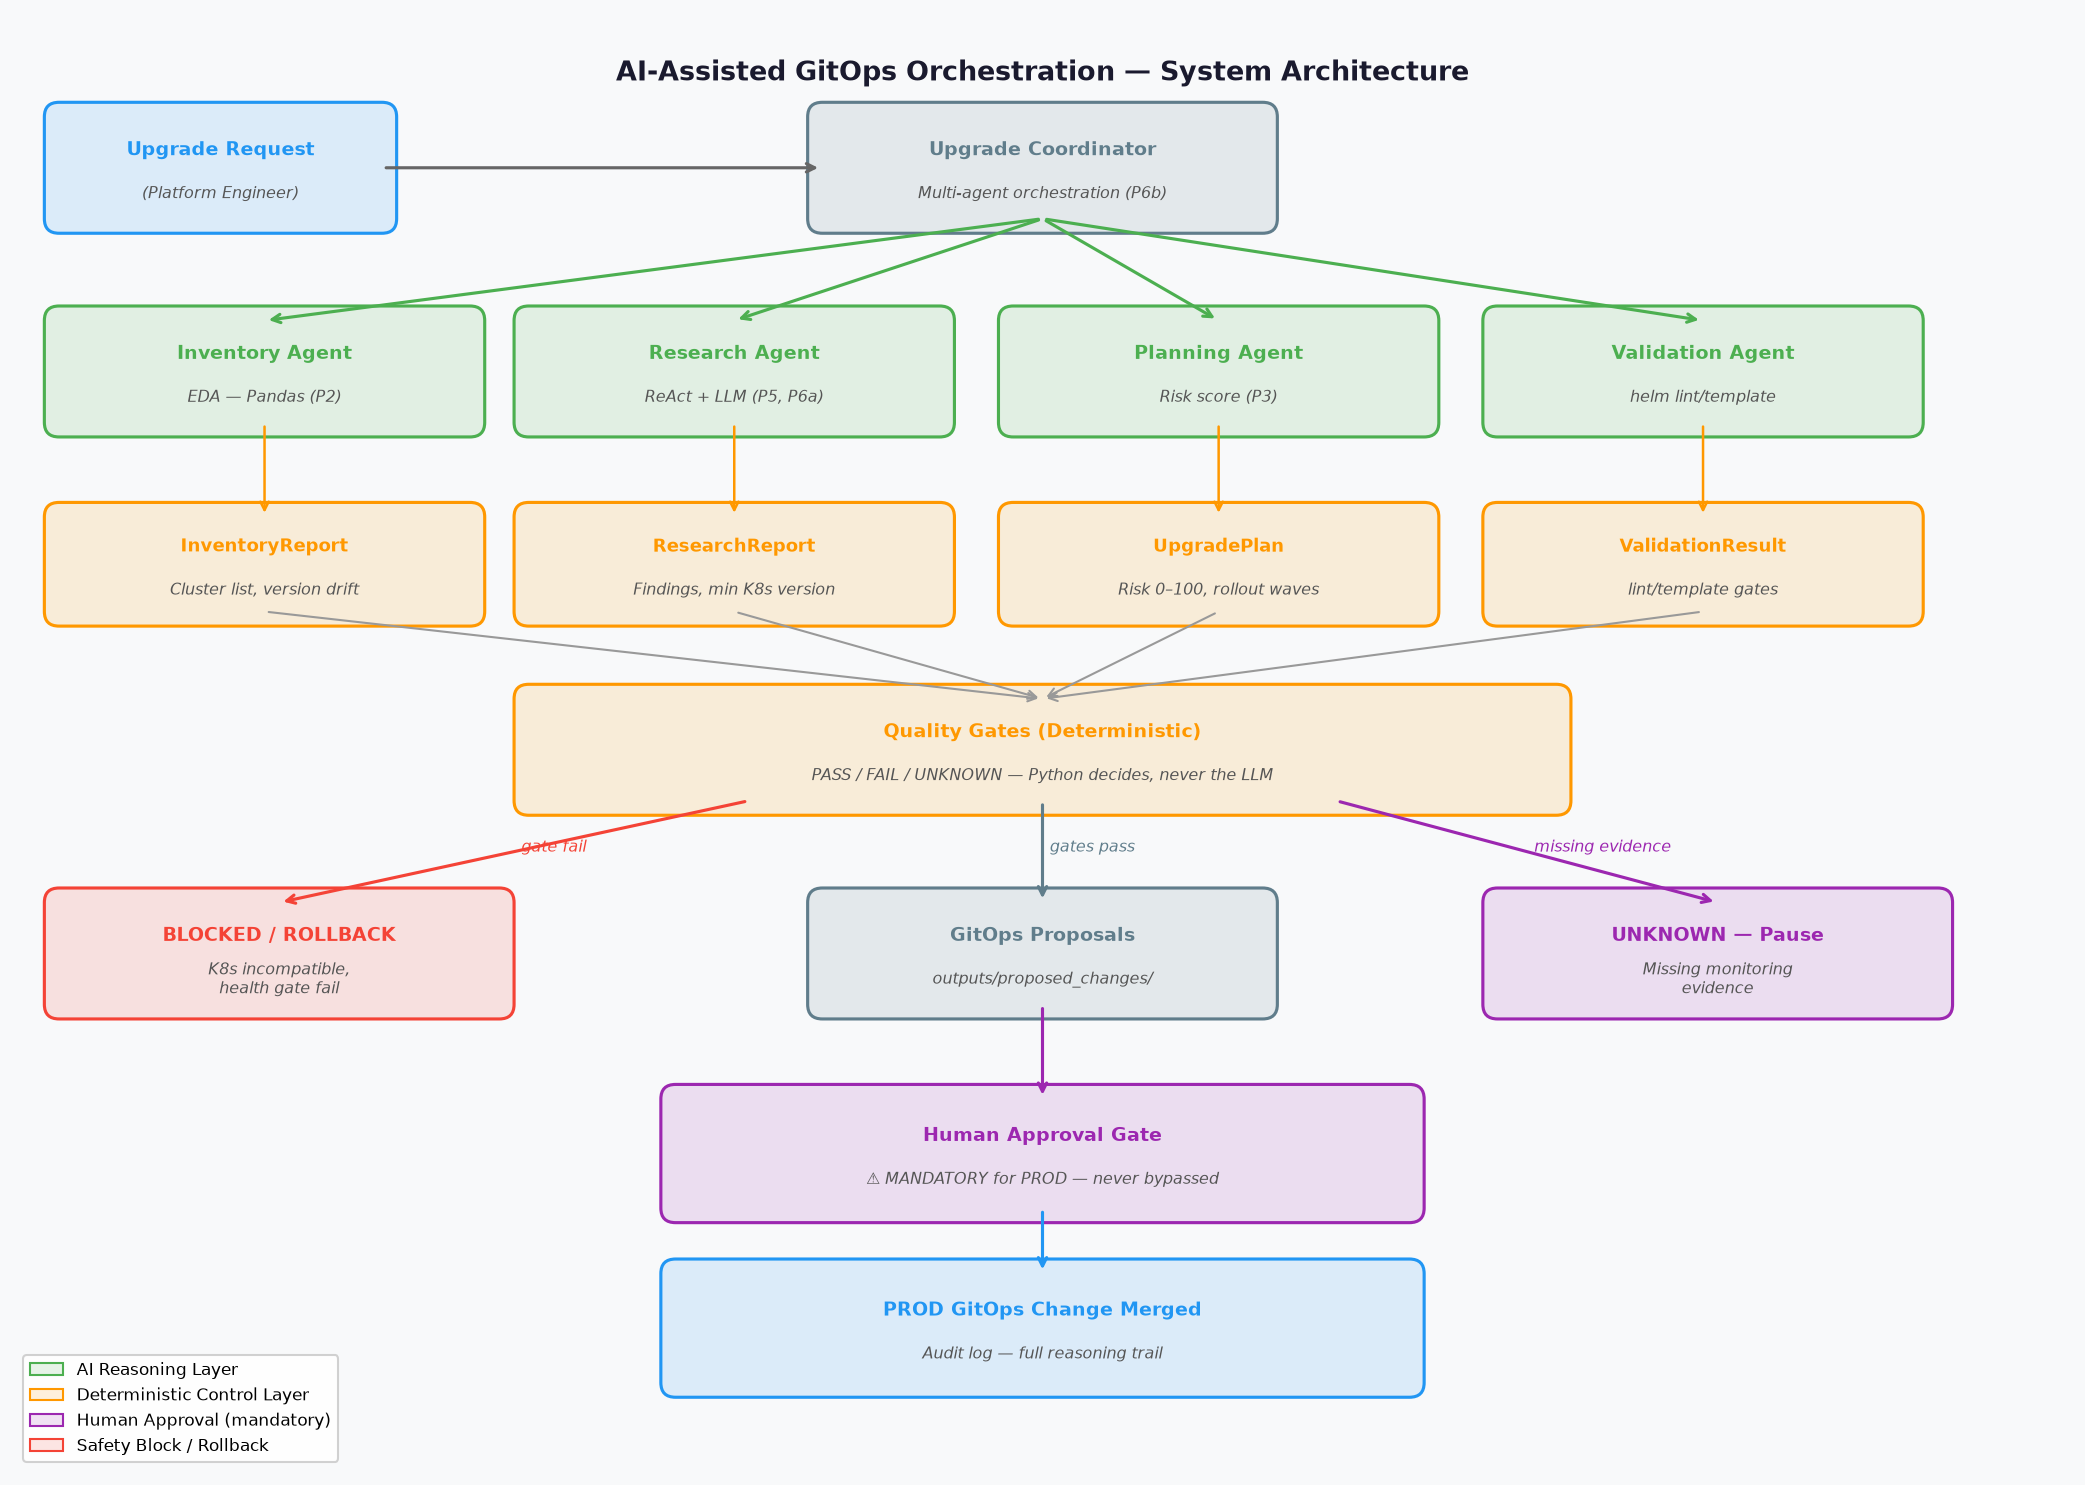

Approved tools exposed through ToolRegistry:


,tool_name,description,input_schema
0,search_release_notes,Search release notes for breaking changes and deprecations,"{""additionalProperties"": false, ""properties"": {""component"": {""title"": ""Component"", ""type"": ""string""}, ""chart_version..."
1,search_runbook,Search upgrade runbooks for rollback and operational guidance,"{""additionalProperties"": false, ""properties"": {""component"": {""title"": ""Component"", ""type"": ""string""}}, ""required"": [..."
2,get_kubernetes_compatibility,Extract minimum Kubernetes version from release notes,"{""additionalProperties"": false, ""properties"": {""component"": {""title"": ""Component"", ""type"": ""string""}, ""chart_version..."


Registry description:
- search_release_notes(component, chart_version): Search release notes for breaking changes and deprecations
- search_runbook(component): Search upgrade runbooks for rollback and operational guidance
- get_kubernetes_compatibility(component, chart_version): Extract minimum Kubernetes version from release notes

Research status : complete
Synthesis note  : kafka-connect chart 0.18.3 (app 7.8.2) has 1 critical/error finding(s). Review breaking changes and Kubernetes compatibi
Findings        : 5
Breaking changes: True
Min Kubernetes  : None

ReAct loop audit trail (per-iteration decisions and observations):


,action,tool,result,evidence
0,research_started,NaN,ReAct loop started: kafka-connect chart 0.18.3,
1,iteration_1_decision,NaN,action=search_release_notes; Release-note evidence is required before assessing,"{""component"": ""kafka-connect"", ""chart_version"": ""0.18.3""}"
2,iteration_1_observation,search_release_notes,succeeded=True; 3 finding(s) from release_notes/kafka-connect-0.18.3.md,"{""component"": ""kafka-connect"", ""chart_version"": ""0.18.3""}"
3,iteration_2_decision,NaN,action=search_runbook; Rollback and operational guidance must be checked.,"{""component"": ""kafka-connect""}"
4,iteration_2_observation,search_runbook,succeeded=True; 2 runbook finding(s) from runbooks/kafka-connect-upgrade.md,"{""component"": ""kafka-connect""}"
5,iteration_3_decision,NaN,action=get_kubernetes_compatibility; Kubernetes version compatibility remains un,"{""component"": ""kafka-connect"", ""chart_version"": ""0.18.3""}"
6,iteration_3_observation,get_kubernetes_compatibility,succeeded=True; min_k8s=not specified,"{""component"": ""kafka-connect"", ""chart_version"": ""0.18.3""}"
7,iteration_4_decision,NaN,"action=finish; All mandatory evidence collected: release notes, runbook, and Kub",{}
8,research_complete,NaN,FINISH accepted after 4 iteration(s). Observations: 3.,


In [8]:
# Display system architecture diagram
from IPython.display import Image as _IPImage
arch_path = PROJECT_ROOT / 'diagrams' / 'architecture.png'
if arch_path.exists():
    display(_IPImage(filename=str(arch_path)))
else:
    print(f'Architecture diagram not found at {arch_path}')

demo_audit_path = OUTPUTS_DIR / 'demo_agent_audit.jsonl'
if demo_audit_path.exists():
    demo_audit_path.unlink()

demo_agent = build_research_agent(
    request_id='DEMO-AGENT',
    audit_log_path=demo_audit_path,
    release_notes_dir=RELEASE_NOTES_DIR,
    runbooks_dir=RUNBOOKS_DIR,
    llm_client=client,
)

tool_catalog = pd.DataFrame([
    {
        'tool_name': tool.name,
        'description': tool.description,
        'input_schema': json.dumps(tool.input_model.model_json_schema()),
    }
    for tool in demo_agent.registry._tools.values()
])

print('Approved tools exposed through ToolRegistry:')
display(tool_catalog)
print('Registry description:')
print(demo_agent.registry.describe_all())

# ── Run the ReAct loop on a demo request and display the audit trail ──────────

demo_request = UpgradeRequest(
    request_id='DEMO-AGENT',
    component='kafka-connect',
    target_chart_version='0.18.3',
    target_app_version='7.8.2',
    departments=['payments'],
    regions=['eu-west-1'],
    requested_by='notebook-demo',
)

demo_report = demo_agent.run(demo_request)

print(f'\nResearch status : {demo_report.status.value}')
print(f'Synthesis note  : {demo_report.synthesis_note[:120]}')
print(f'Findings        : {len(demo_report.findings)}')
print(f'Breaking changes: {demo_report.breaking_changes_detected}')
print(f'Min Kubernetes  : {demo_report.minimum_kubernetes_version}')

# Parse and display per-iteration ReAct audit entries
if demo_audit_path.exists():
    audit_rows = []
    with open(demo_audit_path) as f:
        for line in f:
            try:
                entry = json.loads(line.strip())
                if entry.get('request_id') == 'DEMO-AGENT':
                    audit_rows.append(entry)
            except Exception:
                pass

    # Show decision and observation entries
    react_rows = [
        {
            'action': e['action'],
            'tool': e.get('tool_used', ''),
            'result': (e.get('result', '') or '')[:80],
            'evidence': (e.get('evidence', '') or '')[:60],
        }
        for e in audit_rows
        if any(k in e['action'] for k in ('decision', 'observation', 'finish', 'research'))
    ]
    if react_rows:
        audit_df = pd.DataFrame(react_rows)
        print('\nReAct loop audit trail (per-iteration decisions and observations):')
        display(audit_df)
    else:
        print('(No iteration entries in audit log — confirm demo_audit_path is correct)')


In [9]:
react_excerpts = {
    'ToolRegistry excerpt': '\n'.join(inspect.getsource(ToolRegistry).splitlines()[:25]),
    'UpgradeResearchAgent excerpt': '\n'.join(inspect.getsource(UpgradeResearchAgent).splitlines()[:70]),
    'UpgradeResearchAgent.run excerpt': '\n'.join(inspect.getsource(UpgradeResearchAgent.run).splitlines()[:70]),
}

for title, source in react_excerpts.items():
    print(f'\n{title}\n' + '-' * len(title))
    print(source)



ToolRegistry excerpt
--------------------
class ToolRegistry:
    """
    Registry of approved tools. Only registered tools may be invoked.
    Any call to an unregistered name raises ValueError before execution.
    """
    def __init__(self):
        self._tools: Dict[str, Tool] = {}

    def register(self, tool: Tool) -> None:
        self._tools[tool.name] = tool

    def call(self, name: str, arguments: dict) -> Any:
        if name not in self._tools:
            raise ValueError(f"Unapproved tool: '{name}'")
        return self._tools[name].invoke(arguments)

    def describe_all(self) -> str:
        lines = []
        for t in self._tools.values():
            fields = ", ".join(t.input_model.model_fields.keys())
            lines.append(f"- {t.name}({fields}): {t.description}")
        return "\n".join(lines)

    def list_names(self) -> List[str]:
        return list(self._tools.keys())

UpgradeResearchAgent excerpt
----------------------------
class UpgradeResearchAgent:
 

# 9. Risk Scoring Model

This section is **adapted from Project 3 (Applied ML — LSTM Fraud Detection)**. Instead of a probabilistic fraud classifier, the system uses deterministic feature-style upgrade factors to produce a bounded risk score and categorical risk level.


In [10]:
scenario_file_map = {
    'UPG-2026-001': SCENARIO_DIR / 'successful_upgrade.yaml',
    'UPG-2026-002': SCENARIO_DIR / 'breaking_value_change.yaml',
    'UPG-2026-003': SCENARIO_DIR / 'kubernetes_incompatibility.yaml',
    'UPG-2026-004': SCENARIO_DIR / 'failed_int_rollout.yaml',
    'UPG-2026-005': SCENARIO_DIR / 'missing_observability.yaml',
}

def pick_int_cluster_name(component, departments, regions):
    scoped = filter_affected_clusters(inventory_df, component, departments, regions)
    int_rows = scoped[scoped['environment'].str.upper() == 'INT']
    if not int_rows.empty:
        return int_rows.iloc[0]['cluster_name']
    if not scoped.empty:
        return scoped.iloc[0]['cluster_name']
    return 'unknown'

def build_request_snapshot(request_id, scenario_path):
    scenario = yaml.safe_load(scenario_path.read_text())
    request_data = scenario['request']
    request = UpgradeRequest(
        request_id=request_id,
        component=request_data['component'],
        target_chart_version=str(request_data['target_chart_version']),
        target_app_version=str(request_data['target_app_version']),
        departments=list(request_data['departments']),
        regions=list(request_data['regions']),
        starting_environment=Environment(request_data.get('starting_environment', 'INT')),
        requested_by=request_data['requested_by'],
    )

    cluster_name = pick_int_cluster_name(request.component, request.departments, request.regions)
    monitoring_snapshot = scenario.get('monitoring_snapshot')

    if request_id == 'UPG-2026-005':
        snapshot = HealthSnapshot(
            cluster=cluster_name,
            pod_ready_percent=None,
            restart_count=None,
            error_rate_change_pct=None,
            latency_change_pct=None,
            memory_change_pct=None,
            evidence_available=False,
        )
    elif monitoring_snapshot is None:
        snapshot = None
    else:
        snapshot = HealthSnapshot(cluster=cluster_name, evidence_available=True, **monitoring_snapshot)

    return scenario, request, snapshot

scenario_bundle = [build_request_snapshot(request_id, path) for request_id, path in scenario_file_map.items()]

scenario_catalog_df = pd.DataFrame([
    {
        'request_id': request.request_id,
        'scenario_name': scenario['name'],
        'component': request.component,
        'target_chart_version': request.target_chart_version,
        'target_app_version': request.target_app_version,
        'departments': ', '.join(request.departments),
        'regions': ', '.join(request.regions),
        'snapshot_present': snapshot is not None,
    }
    for scenario, request, snapshot in scenario_bundle
])

display(scenario_catalog_df)


,request_id,scenario_name,component,target_chart_version,target_app_version,departments,regions,snapshot_present
0,UPG-2026-001,Successful patch upgrade,kafka-connect,0.18.3,7.8.2,payments,eu-west-1,True
1,UPG-2026-002,Breaking Helm value key renamed,kafka-connect,0.19.0,8.0.2,payments,eu-west-1,True
2,UPG-2026-003,Kubernetes version incompatibility,kafka-connect,0.19.0,8.0.2,vehicle-services,af-south-1,False
3,UPG-2026-004,Failed INT deployment,kafka-connect,0.19.0,8.0.2,payments,eu-west-1,True
4,UPG-2026-005,Missing observability evidence,prometheus,25.2.0,2.52.0,vehicle-services,eu-west-1,True


In [11]:
print('Risk scoring below is adapted from Project 3 (Applied ML — LSTM Fraud Detection).')

risk_rules = load_risk_rules(RISK_RULES_PATH)
preflight_artifacts = {}
risk_rows = []

for scenario, request, snapshot in scenario_bundle:
    inventory_report, scoped_df = run_inventory_analysis(
        request_id=request.request_id,
        component=request.component,
        departments=request.departments,
        regions=request.regions,
        inventory_path=INVENTORY_PATH,
        history_path=HISTORY_PATH,
        dep_path=DEPENDENCY_PATH,
    )
    research_report = run_upgrade_research(
        request_id=request.request_id,
        component=request.component,
        target_chart_version=request.target_chart_version,
        target_app_version=request.target_app_version,
        release_notes_dir=RELEASE_NOTES_DIR,
        runbooks_dir=RUNBOOKS_DIR,
    )
    history_subset = analyse_upgrade_history(HISTORY_PATH, request.component)
    success_rate = upgrade_success_rate(history_subset)
    risk_score, risk_level, risk_factors = calculate_risk_score(
        inventory_report,
        research_report,
        success_rate,
        weights=risk_rules['weights'],
        thresholds=risk_rules['thresholds'],
    )
    plan = build_upgrade_plan(
        request_id=request.request_id,
        inventory_report=inventory_report,
        research_report=research_report,
        history_success_rate=success_rate,
        risk_rules_path=RISK_RULES_PATH,
    )

    preflight_artifacts[request.request_id] = {
        'scenario': scenario,
        'request': request,
        'snapshot': snapshot,
        'inventory_report': inventory_report,
        'research_report': research_report,
        'history_subset': history_subset,
        'plan': plan,
    }

    risk_rows.append({
        'request_id': request.request_id,
        'scenario_name': scenario['name'],
        'component': request.component,
        'risk_score': risk_score,
        'risk_level': risk_level.value,
        'affected_clusters': inventory_report.total_clusters,
        'research_findings': len(research_report.findings),
        'history_success_rate': None if pd.isna(success_rate) else round(float(success_rate), 3),
    })

risk_df = pd.DataFrame(risk_rows).sort_values('request_id').reset_index(drop=True)
display(risk_df)

risk_factor_rows = []
for request_id, artifact in preflight_artifacts.items():
    for factor_name, factor_info in artifact['plan'].risk_factors.items():
        risk_factor_rows.append({
            'request_id': request_id,
            'factor_name': factor_name,
            'weight': factor_info['weight'],
            'evidence': factor_info['evidence'],
        })

risk_factor_df = pd.DataFrame(risk_factor_rows)
display(risk_factor_df)


Risk scoring below is adapted from Project 3 (Applied ML — LSTM Fraud Detection).


,request_id,scenario_name,component,risk_score,risk_level,affected_clusters,research_findings,history_success_rate
0,UPG-2026-001,Successful patch upgrade,kafka-connect,20,low,2,5,0.857
1,UPG-2026-002,Breaking Helm value key renamed,kafka-connect,45,medium,2,7,0.857
2,UPG-2026-003,Kubernetes version incompatibility,kafka-connect,70,high,2,7,0.857
3,UPG-2026-004,Failed INT deployment,kafka-connect,45,medium,2,7,0.857
4,UPG-2026-005,Missing observability evidence,prometheus,20,low,2,2,1.000


,request_id,factor_name,weight,evidence
0,UPG-2026-001,breaking_helm_value_change,20,Breaking changes: []
1,UPG-2026-001,stateful_or_critical_component,10,2 high/critical cluster(s)
2,UPG-2026-001,proven_rollback_procedure,-10,Runbook exists with documented rollback steps
3,UPG-2026-002,major_app_version_change,25,App version change to 8.0.2
4,UPG-2026-002,breaking_helm_value_change,20,"Breaking changes: ['Deprecations', '`image.pullPolicy: Always` is deprecated; use `image.pullPolicy: IfNotPresent` i..."
5,UPG-2026-002,stateful_or_critical_component,10,2 high/critical cluster(s)
6,UPG-2026-002,proven_rollback_procedure,-10,Runbook exists with documented rollback steps
7,UPG-2026-003,major_app_version_change,25,App version change to 8.0.2
8,UPG-2026-003,breaking_helm_value_change,20,"Breaking changes: ['Deprecations', '`image.pullPolicy: Always` is deprecated; use `image.pullPolicy: IfNotPresent` i..."
9,UPG-2026-003,kubernetes_incompatibility,25,"Cluster vehicles-afs-int runs K8s 1.26, chart requires >=1.27"


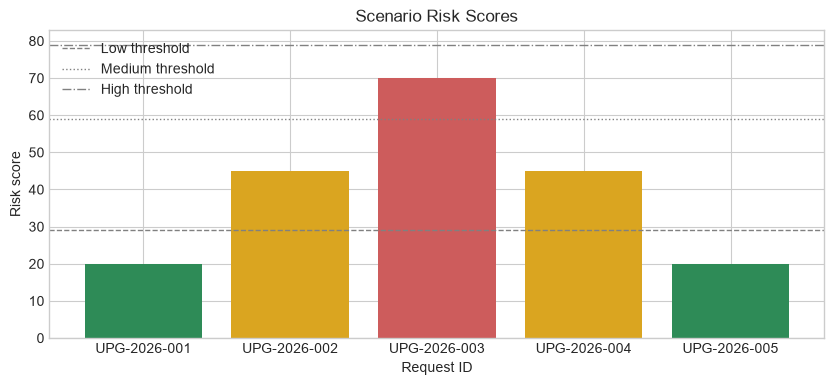

In [12]:
color_map = {'low': '#2E8B57', 'medium': '#DAA520', 'high': '#CD5C5C', 'critical': '#8B0000'}
bar_colors = [color_map[level] for level in risk_df['risk_level']]

plt.figure(figsize=(10, 4))
plt.bar(risk_df['request_id'], risk_df['risk_score'], color=bar_colors)
plt.axhline(29, color='gray', linestyle='--', linewidth=1, label='Low threshold')
plt.axhline(59, color='gray', linestyle=':', linewidth=1, label='Medium threshold')
plt.axhline(79, color='gray', linestyle='-.', linewidth=1, label='High threshold')
plt.title('Scenario Risk Scores')
plt.xlabel('Request ID')
plt.ylabel('Risk score')
plt.legend(loc='upper left')
plt.show()


# 10. Upgrade Orchestration — 5 Scenario Runs

This section is **adapted from Project 6b (agentic-ai-beaver-choice multi-agent pattern)**. The `UpgradeCoordinator` runs the full workflow: the bounded ReAct research agent gathers evidence, then deterministic components calculate risk, validate Helm, evaluate health, and propose GitOps changes. All safety gates are outside the agent's authority.


In [13]:
def parse_validation_overall(validation_results):
    joined = ' '.join(validation_results)
    if 'FAIL' in joined:
        return 'FAIL'
    if 'UNKNOWN' in joined:
        return 'UNKNOWN'
    if 'PASS' in joined:
        return 'PASS'
    return 'N/A'

def parse_health_overall(health_results):
    joined = ' '.join(health_results)
    if 'UNKNOWN' in joined:
        return 'UNKNOWN'
    if 'FAIL' in joined:
        return 'FAIL'
    if 'PASS' in joined:
        return 'PASS'
    return 'N/A'

coordinator = UpgradeCoordinator(PROJECT_ROOT, llm_client=client, verbose=False)
scenario_results = []

print('Running 5 orchestrated scenarios...')

for scenario, request, snapshot in scenario_bundle:
    run_output_dir = OUTPUTS_DIR / 'notebook_runs' / request.request_id
    if run_output_dir.exists():
        shutil.rmtree(run_output_dir)
    run_output_dir.mkdir(parents=True, exist_ok=True)

    coordinator.output_dir = run_output_dir
    coordinator.audit_log_path = coordinator.output_dir / f'audit_log_{request.request_id}.jsonl'
    coordinator.state = UpgradeState.REQUESTED

    report = coordinator.run(request, snapshot)

    plan_path = run_output_dir / 'upgrade_plan.json'
    plan_payload = json.loads(plan_path.read_text()) if plan_path.exists() else {}
    audit_entries = load_audit_log(coordinator.audit_log_path)

    scenario_results.append({
        'scenario_id': scenario['scenario_id'],
        'scenario_name': scenario['name'],
        'request_id': request.request_id,
        'component': request.component,
        'final_state': report.final_state.value,
        'risk_level': report.risk_level.value,
        'risk_score': plan_payload.get('risk_score'),
        'requires_human_action': report.requires_human_action,
        'validation_overall': parse_validation_overall(report.validation_results),
        'health_overall': parse_health_overall(report.health_results),
        'recommendation': report.recommendation,
        'validation_results': report.validation_results,
        'health_results': report.health_results,
        'proposed_changes': report.proposed_changes,
        'audit_trail_length': report.audit_trail_length,
        'audit_log_path': str(coordinator.audit_log_path),
        'output_dir': str(run_output_dir),
    })

    print(f"{request.request_id} | {scenario['name']} | state={report.final_state.value} | risk={report.risk_level.value} | health={parse_health_overall(report.health_results)}")

scenario_results_df = pd.DataFrame([
    {
        'request_id': row['request_id'],
        'scenario_name': row['scenario_name'],
        'component': row['component'],
        'risk_score': row['risk_score'],
        'risk_level': row['risk_level'],
        'final_state': row['final_state'],
        'validation_overall': row['validation_overall'],
        'health_overall': row['health_overall'],
        'requires_human_action': row['requires_human_action'],
        'audit_trail_length': row['audit_trail_length'],
        'recommendation': row['recommendation'],
    }
    for row in scenario_results
])

display(scenario_results_df)


Running 5 orchestrated scenarios...

[Phase 1] Inventory Agent — analysing cluster inventory...

[Phase 2] Research Agent — analysing release notes and runbooks...

[Phase 3] Planning Agent — calculating risk score and upgrade plan...

[Phase 4] Validation Agent — helm lint, template, and value checks...



[Phase 5] Health evaluation — evaluating INT deployment metrics...

[Phase 6] Generating proposed GitOps changes...
UPG-2026-001 | Successful patch upgrade | state=AwaitingApproval | risk=low | health=PASS

[Phase 1] Inventory Agent — analysing cluster inventory...

[Phase 2] Research Agent — analysing release notes and runbooks...

[Phase 3] Planning Agent — calculating risk score and upgrade plan...

[Phase 4] Validation Agent — helm lint, template, and value checks...

[Phase 5] Health evaluation — evaluating INT deployment metrics...

[Phase 6] Generating proposed GitOps changes...
UPG-2026-002 | Breaking Helm value key renamed | state=AwaitingApproval | risk=medium | health=PASS

[Phase 1] Inventory Agent — analysing cluster inventory...

[Phase 2] Research Agent — analysing release notes and runbooks...

[Phase 3] Planning Agent — calculating risk score and upgrade plan...
UPG-2026-003 | Kubernetes version incompatibility | state=Blocked | risk=high | health=N/A

[Phase 1] Inven


[Phase 2] Research Agent — analysing release notes and runbooks...

[Phase 3] Planning Agent — calculating risk score and upgrade plan...

[Phase 4] Validation Agent — helm lint, template, and value checks...

[Phase 5] Health evaluation — evaluating INT deployment metrics...
UPG-2026-005 | Missing observability evidence | state=Paused | risk=low | health=UNKNOWN


,request_id,scenario_name,component,risk_score,risk_level,final_state,validation_overall,health_overall,requires_human_action,audit_trail_length,recommendation
0,UPG-2026-001,Successful patch upgrade,kafka-connect,20,low,AwaitingApproval,PASS,PASS,True,20,AWAITING HUMAN APPROVAL: INT validation passed. Review proposed changes and approve PROD deployment.
1,UPG-2026-002,Breaking Helm value key renamed,kafka-connect,45,medium,AwaitingApproval,PASS,PASS,True,20,AWAITING HUMAN APPROVAL: INT validation passed. Review proposed changes and approve PROD deployment.
2,UPG-2026-003,Kubernetes version incompatibility,kafka-connect,70,high,Blocked,N/A,N/A,True,15,"BLOCKED: Kubernetes version incompatibility. Chart requires K8s >=1.27. Incompatible clusters: ['vehicles-afs-int', ..."
3,UPG-2026-004,Failed INT deployment,kafka-connect,45,medium,INTFailed,PASS,FAIL,True,18,ROLLBACK RECOMMENDED: INT deployment failed health gates. Do not promote to PROD.
4,UPG-2026-005,Missing observability evidence,prometheus,20,low,Paused,PASS,UNKNOWN,True,18,PAUSED: Monitoring evidence unavailable. UNKNOWN is not PASS. Human investigation required before any promotion deci...


# 11. GitOps Change Generation

Proposed changes are generated as reviewable GitOps artifacts. The system writes unified diffs and PR-style summaries, but it does **not** auto-commit or auto-promote to production.


In [14]:
gitops_summary_df = pd.DataFrame([
    {
        'request_id': row['request_id'],
        'scenario_name': row['scenario_name'],
        'diff_files': len([p for p in row['proposed_changes'] if isinstance(p, str) and p.endswith('.diff')]),
        'pr_files': len([p for p in row['proposed_changes'] if isinstance(p, str) and p.endswith('-pr.md')]),
        'output_dir': row['output_dir'],
    }
    for row in scenario_results
])
display(gitops_summary_df)

for request_id in ['UPG-2026-001', 'UPG-2026-002', 'UPG-2026-005']:
    row = next(item for item in scenario_results if item['request_id'] == request_id)
    diff_files = [Path(p) for p in row['proposed_changes'] if isinstance(p, str) and p.endswith('.diff')]
    pr_files = [Path(p) for p in row['proposed_changes'] if isinstance(p, str) and p.endswith('-pr.md')]

    if diff_files:
        print(f'\n===== Diff preview for {request_id}: {diff_files[0].name} =====')
        print('\n'.join(diff_files[0].read_text().splitlines()[:40]))
    if pr_files:
        print(f'\n----- PR description preview for {request_id}: {pr_files[0].name} -----')
        print('\n'.join(pr_files[0].read_text().splitlines()[:25]))


,request_id,scenario_name,diff_files,pr_files,output_dir
0,UPG-2026-001,Successful patch upgrade,2,2,/Users/sheugumbie/projects/udacity/ai-helm-upgrade-orchestrator/outputs/notebook_runs/UPG-2026-001
1,UPG-2026-002,Breaking Helm value key renamed,2,2,/Users/sheugumbie/projects/udacity/ai-helm-upgrade-orchestrator/outputs/notebook_runs/UPG-2026-002
2,UPG-2026-003,Kubernetes version incompatibility,0,0,/Users/sheugumbie/projects/udacity/ai-helm-upgrade-orchestrator/outputs/notebook_runs/UPG-2026-003
3,UPG-2026-004,Failed INT deployment,0,0,/Users/sheugumbie/projects/udacity/ai-helm-upgrade-orchestrator/outputs/notebook_runs/UPG-2026-004
4,UPG-2026-005,Missing observability evidence,0,0,/Users/sheugumbie/projects/udacity/ai-helm-upgrade-orchestrator/outputs/notebook_runs/UPG-2026-005



===== Diff preview for UPG-2026-001: payments-euw1-int-int.diff =====
--- current/environments/department-a/eu-west-1/int/connect.yaml+++ proposed/environments/department-a/eu-west-1/int/connect.yaml@@ -1,26 +1,25 @@-# Kafka Connect values — payments / eu-west-1 / INT
+bootstrapServers: kafka-broker-int.eu-west-1.internal:9092
+chart:
+  name: kafka-connect
+  repository: internal-platform
+  version: 0.18.3
 component: kafka-connect
-chart:
-  repository: internal-platform
-  name: kafka-connect
-  version: 0.18.2
 image:
+  pullPolicy: IfNotPresent
   repository: confluentinc/cp-kafka-connect
-  tag: 7.8.1
-  pullPolicy: IfNotPresent
-replicaCount: 2
+  tag: 7.8.2
 kafka:
   connect:
-    config.storage.replication.factor: "3"
-    offset.storage.replication.factor: "3"
-    status.storage.replication.factor: "3"
+    config.storage.replication.factor: '3'
     group.id: payments-euw1-int-connect
-bootstrapServers: "kafka-broker-int.eu-west-1.internal:9092"
-schemaRegistryUrl: "http

# 12. Quantitative Evaluation

This section converts scenario outcomes into compact evaluation tables and charts so the orchestration behaviour can be assessed across the five controlled experiments.


In [15]:
evaluation_df = scenario_results_df.copy()
evaluation_df['promotion_ready'] = evaluation_df['final_state'].eq('AwaitingApproval') & evaluation_df['health_overall'].eq('PASS')
evaluation_df['blocked_or_failed'] = evaluation_df['final_state'].isin(['Blocked', 'INTFailed']) | evaluation_df['health_overall'].isin(['FAIL', 'UNKNOWN'])

display(evaluation_df)

summary_table = pd.DataFrame([
    {'metric': 'Total scenarios', 'value': len(evaluation_df)},
    {'metric': 'Promotion-ready after INT', 'value': int(evaluation_df['promotion_ready'].sum())},
    {'metric': 'Blocked or failed scenarios', 'value': int(evaluation_df['blocked_or_failed'].sum())},
    {'metric': 'Human approval required', 'value': int(evaluation_df['requires_human_action'].sum())},
    {'metric': 'Average risk score', 'value': round(evaluation_df['risk_score'].dropna().mean(), 2)},
])
display(summary_table)


,request_id,scenario_name,component,risk_score,risk_level,final_state,validation_overall,health_overall,requires_human_action,audit_trail_length,recommendation,promotion_ready,blocked_or_failed
0,UPG-2026-001,Successful patch upgrade,kafka-connect,20,low,AwaitingApproval,PASS,PASS,True,20,AWAITING HUMAN APPROVAL: INT validation passed. Review proposed changes and approve PROD deployment.,True,False
1,UPG-2026-002,Breaking Helm value key renamed,kafka-connect,45,medium,AwaitingApproval,PASS,PASS,True,20,AWAITING HUMAN APPROVAL: INT validation passed. Review proposed changes and approve PROD deployment.,True,False
2,UPG-2026-003,Kubernetes version incompatibility,kafka-connect,70,high,Blocked,N/A,N/A,True,15,"BLOCKED: Kubernetes version incompatibility. Chart requires K8s >=1.27. Incompatible clusters: ['vehicles-afs-int', ...",False,True
3,UPG-2026-004,Failed INT deployment,kafka-connect,45,medium,INTFailed,PASS,FAIL,True,18,ROLLBACK RECOMMENDED: INT deployment failed health gates. Do not promote to PROD.,False,True
4,UPG-2026-005,Missing observability evidence,prometheus,20,low,Paused,PASS,UNKNOWN,True,18,PAUSED: Monitoring evidence unavailable. UNKNOWN is not PASS. Human investigation required before any promotion deci...,False,True


,metric,value
0,Total scenarios,5.0
1,Promotion-ready after INT,2.0
2,Blocked or failed scenarios,3.0
3,Human approval required,5.0
4,Average risk score,40.0


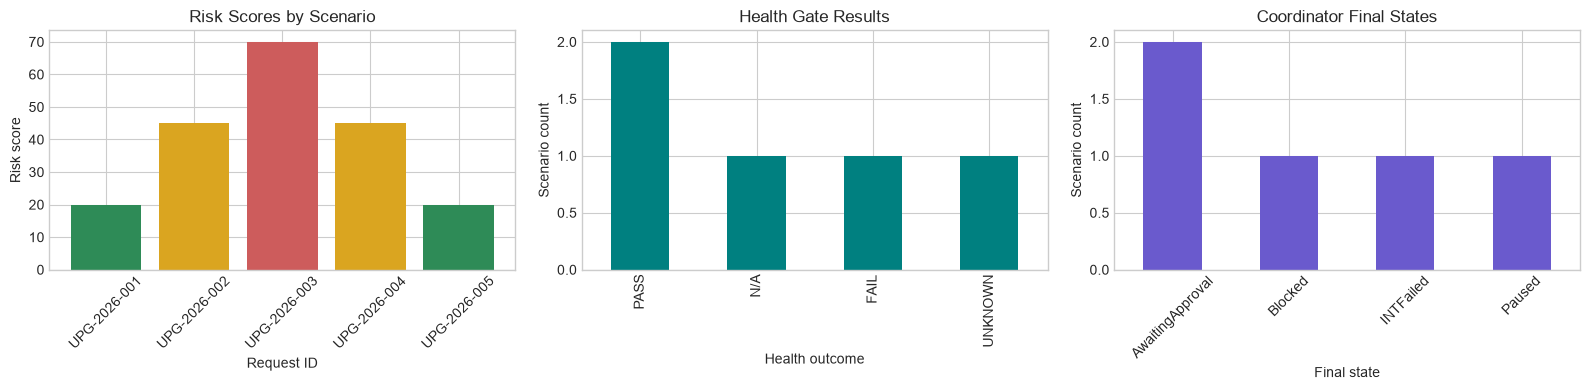

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(evaluation_df['request_id'], evaluation_df['risk_score'], color=[color_map[level] for level in evaluation_df['risk_level']])
axes[0].set_title('Risk Scores by Scenario')
axes[0].set_xlabel('Request ID')
axes[0].set_ylabel('Risk score')
axes[0].tick_params(axis='x', rotation=45)

evaluation_df['health_overall'].value_counts().plot(kind='bar', ax=axes[1], color='teal', title='Health Gate Results')
axes[1].set_xlabel('Health outcome')
axes[1].set_ylabel('Scenario count')

evaluation_df['final_state'].value_counts().plot(kind='bar', ax=axes[2], color='slateblue', title='Coordinator Final States')
axes[2].set_xlabel('Final state')
axes[2].set_ylabel('Scenario count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# 13. Failure Analysis

The most important scenarios are not the clean successes, but the cases where the system blocks, pauses, or recommends rollback. This section inspects those outcomes directly.


In [17]:
failure_df = evaluation_df[
    evaluation_df['final_state'].isin(['Blocked', 'INTFailed']) | evaluation_df['health_overall'].isin(['UNKNOWN', 'FAIL'])
].copy()

display(failure_df[['request_id', 'scenario_name', 'final_state', 'health_overall', 'recommendation']])

failure_root_causes = []
for row in scenario_results:
    if row['request_id'] in set(failure_df['request_id']):
        failure_root_causes.append({
            'request_id': row['request_id'],
            'scenario_name': row['scenario_name'],
            'primary_signal': row['recommendation'],
            'validation_results': ' | '.join(row['validation_results']),
            'health_results': ' | '.join(row['health_results']),
            'audit_trail_length': row['audit_trail_length'],
        })

display(pd.DataFrame(failure_root_causes))


,request_id,scenario_name,final_state,health_overall,recommendation
2,UPG-2026-003,Kubernetes version incompatibility,Blocked,N/A,"BLOCKED: Kubernetes version incompatibility. Chart requires K8s >=1.27. Incompatible clusters: ['vehicles-afs-int', ..."
3,UPG-2026-004,Failed INT deployment,INTFailed,FAIL,ROLLBACK RECOMMENDED: INT deployment failed health gates. Do not promote to PROD.
4,UPG-2026-005,Missing observability evidence,Paused,UNKNOWN,PAUSED: Monitoring evidence unavailable. UNKNOWN is not PASS. Human investigation required before any promotion deci...


,request_id,scenario_name,primary_signal,validation_results,health_results,audit_trail_length
0,UPG-2026-003,Kubernetes version incompatibility,"BLOCKED: Kubernetes version incompatibility. Chart requires K8s >=1.27. Incompatible clusters: ['vehicles-afs-int', ...",No validation run,No health evaluation,15
1,UPG-2026-004,Failed INT deployment,ROLLBACK RECOMMENDED: INT deployment failed health gates. Do not promote to PROD.,payments-euw1-int: PASS,Overall: FAIL | pod_ready_percent=50.0 < 100 | restart_count=8 > 2 | error_rate_change=28.5% > 5.0% | latency_change...,18
2,UPG-2026-005,Missing observability evidence,PAUSED: Monitoring evidence unavailable. UNKNOWN is not PASS. Human investigation required before any promotion deci...,vehicles-euw1-int: PASS,Health: UNKNOWN — No monitoring evidence available — UNKNOWN state. Human investigation required.,18


In [18]:
for request_id in failure_df['request_id']:
    row = next(item for item in scenario_results if item['request_id'] == request_id)
    audit_entries = load_audit_log(row['audit_log_path'])
    audit_tail = pd.DataFrame([
        {
            'timestamp': entry.timestamp,
            'agent': entry.agent,
            'action': entry.action,
            'result': entry.result,
        }
        for entry in audit_entries[-5:]
    ])
    print(f'\nAudit trail excerpt for {request_id} ({row["scenario_name"]})')
    display(audit_tail)



Audit trail excerpt for UPG-2026-003 (Kubernetes version incompatibility)


,timestamp,agent,action,result
0,2026-07-26 13:14:24.952562+00:00,UpgradeResearchAgent,research_complete,FINISH accepted after 4 iteration(s). Observations: 3.
1,2026-07-26 13:14:24.952636+00:00,UpgradeResearchAgent,report_built,"breaking=True, min_k8s=1.27, findings=7"
2,2026-07-26 13:14:24.954993+00:00,PlanningAgent,plan_created,Risk: 70/100 (HIGH)
3,2026-07-26 13:14:24.955058+00:00,Coordinator,state_transition,Analysed → Planned: Risk score: 70/100 (high)
4,2026-07-26 13:14:24.955119+00:00,Coordinator,state_transition,"Planned → Blocked: K8s incompatibility: ['vehicles-afs-int', 'vehicles-afs-prod']"



Audit trail excerpt for UPG-2026-004 (Failed INT deployment)


,timestamp,agent,action,result
0,2026-07-26 13:14:24.963018+00:00,Coordinator,state_transition,Analysed → Planned: Risk score: 45/100 (medium)
1,2026-07-26 13:14:25.043561+00:00,ValidationAgent,validation_complete,payments-euw1-int: PASS
2,2026-07-26 13:14:25.043764+00:00,Coordinator,state_transition,Planned → Validated: Static validation passed
3,2026-07-26 13:14:25.043949+00:00,Coordinator,health_evaluation,Health gate: FAIL
4,2026-07-26 13:14:25.044001+00:00,Coordinator,state_transition,Validated → INTFailed: INT health gates failed



Audit trail excerpt for UPG-2026-005 (Missing observability evidence)


,timestamp,agent,action,result
0,2026-07-26 13:14:25.054839+00:00,Coordinator,state_transition,Analysed → Planned: Risk score: 20/100 (low)
1,2026-07-26 13:14:25.140873+00:00,ValidationAgent,validation_complete,vehicles-euw1-int: PASS
2,2026-07-26 13:14:25.141088+00:00,Coordinator,state_transition,Planned → Validated: Static validation passed
3,2026-07-26 13:14:25.141277+00:00,Coordinator,health_evaluation,Health gate: UNKNOWN
4,2026-07-26 13:14:25.141343+00:00,Coordinator,state_transition,"Validated → Paused: Missing monitoring evidence — UNKNOWN state, human investigation required"


# 14. Ethical Safeguards Demonstration

This section demonstrates three explicit safeguards:
1. secret-like content is rejected,
2. missing monitoring evidence yields `UNKNOWN`, not `PASS`, and
3. PROD changes always require human approval.


In [19]:
secret_manifest = """
apiVersion: v1
kind: Secret
metadata:
  name: db-credentials
type: Opaque
data:
  password: c3VwZXJzZWNyZXQ=
"""

secret_detected = _detect_secrets(secret_manifest)
secret_gate = GateResult.FAIL if secret_detected else GateResult.PASS

print('Secret detected:', secret_detected)
print('Secret detection gate result:', secret_gate.value)


Secret detected: True
Secret detection gate result: FAIL


In [20]:
gates_config = load_quality_gates(QUALITY_GATES_PATH)
unknown_health = evaluate_health(None, gates_config)

print('None snapshot overall gate:', unknown_health.overall.value)
print('Notes:', unknown_health.notes)
print('Global PROD approval policy:', gates_config['global']['require_human_prod_approval'])

approval_evidence = []
for row in scenario_results:
    pr_files = [Path(p) for p in row['proposed_changes'] if isinstance(p, str) and p.endswith('-pr.md')]
    approval_evidence.append({
        'request_id': row['request_id'],
        'final_state': row['final_state'],
        'requires_human_action': row['requires_human_action'],
        'pr_mentions_human_approval': any('Requires human approval before PROD deployment.' in p.read_text() for p in pr_files),
    })

display(pd.DataFrame(approval_evidence))


None snapshot overall gate: UNKNOWN
Notes: ['No monitoring evidence available — UNKNOWN state. Human investigation required.']
Global PROD approval policy: True


,request_id,final_state,requires_human_action,pr_mentions_human_approval
0,UPG-2026-001,AwaitingApproval,True,True
1,UPG-2026-002,AwaitingApproval,True,True
2,UPG-2026-003,Blocked,True,False
3,UPG-2026-004,INTFailed,True,False
4,UPG-2026-005,Paused,True,False


# 15. Limitations and Responsible AI

This notebook demonstrates a realistic orchestration pattern, but it remains a **bounded research artifact** rather than a production control plane.

Key limitations:
- The data is synthetic and intentionally compact.
- Risk scoring is deterministic and interpretable, but not predictive in the statistical-learning sense.
- The LLM is used only for synthesis; it does not make gate decisions, but its summaries can still vary if live credentials are available.
- Helm validation is chart-local; the notebook does not connect to a live Kubernetes control plane.
- GitOps changes are proposed artifacts only; no branch, PR, or deployment is executed automatically.

Responsible AI safeguards used throughout the system:
- retrieved documents are treated as data, not instructions,
- missing evidence produces `UNKNOWN`,
- schema-validated models constrain inter-agent communication,
- audit logs preserve accountability, and
- human approval remains mandatory before PROD promotion.


# 16. Conclusion

The integrated notebook shows that safe multi-cluster Helm upgrade orchestration can be framed as a disciplined combination of **EDA, deterministic risk modelling, constrained agent design, validation gates, and GitOps review artifacts**.

The strongest result is not that some scenarios succeed. It is that the system reliably distinguishes between:
- **safe-to-review** upgrades,
- **rollback-required** outcomes,
- **compatibility blocks**, and
- **unknown-evidence pauses**.

That separation is the core of responsible AI-assisted platform automation.
